# Machine Learning   
## First Assignment   
#### Dimitrios Roufos, 5090   
#### Charalampos Sapranidis, 4969 (economics)

# Part 1: Direct Image-Based Classification using a CNN

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

C:\Users\roufosdimitris\anaconda3\envs\ml311\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Datasets

### 1.1 Train and Validation Dataset Class

In [26]:
train_dir = 'data/train-images/train'
label_dict = {'pleasant':1, 'unpleasant':0}

In [77]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os

class TrainDataset(Dataset):
    def __init__(self, root_dir, label_dict, transform=None, mode='train', device='cpu'):
        self.samples = []
        self.transform = transform
        self.label_dict = label_dict
        self.device = device

        all_samples = []
        for label in os.listdir(root_dir):
            label_dir = os.path.join(root_dir, label)
            if not os.path.isdir(label_dir): continue
            for img_name in os.listdir(label_dir):
                img_path = os.path.join(label_dir, img_name)
                all_samples.append((img_path, label_dict[label]))

        # add every 5th element to validation set
        self.samples = [
            s for i, s in enumerate(all_samples)
            if (i % 5 != 0 if mode == 'train' else i % 5 == 0)
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception as e:
            print(f"Failed to load {img_path}: {e}")
            return torch.zeros(3, 224, 224), -1

### 1.2 Test Dataset Class

In [28]:
test_dir = 'data/TEST_images/TEST_images'
index_path = 'data/Test-IDs.csv'

In [29]:
import pandas as pd
class TestDataset(Dataset):
    def __init__(self, test_dir, index_path, transform=None, device='cpu'):
        #self.image_paths = []
        self.index_list = []
        self.test_ids = pd.read_csv(index_path)
        self.samples = []

        self.transform = transform
        self.device = device

        for img_name in os.listdir(test_dir):
            img_path = os.path.join(test_dir, img_name)  # create OS independent path
            row = test_ids.loc[test_ids['Filename'] == img_name]
            self.index_list.append(row['ID'].to_string(index=False)) # appends just the value, without extra info
            self.samples.append((img_path, row['ID'].to_string(index=False)))
    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, index = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img
        except Exception as e:
            print(f"Failed to load {img_path}: {e}")
            return torch.zeros(3, 224, 224), -1

    def get_index_list(self):
        return self.index_list

### 1.3 Transform

In [41]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # mean for R, G, B
                     [0.229, 0.224, 0.225])      # std for R, G, B
])

### 1.4 Create Sets

In [42]:
train_dataset = TrainDataset(
    root_dir=train_dir,
    label_dict=label_dict,
    transform=transform,
    mode='train',
    device=device
)

val_dataset = TrainDataset(
    root_dir=train_dir,
    label_dict=label_dict,
    transform=transform,
    mode='val',
    device=device
)

test_dataset = TestDataset(
    test_dir=test_dir,
    index_path=index_path,
    transform=transform,
    device=device
)

In [107]:
pos = 0
neg = 0

for i in range(len(train_dataset)):
    if train_dataset[i][1] == 0:
        pos += 1
    else: 
        neg += 1

print(f'  Training Dataset (pleasant/unpleasant) ratio: {pos/neg}')

pos = 0
neg = 0

for i in range(len(val_dataset)):
    if val_dataset[i][1] == 0:
        pos += 1
    else: 
        neg += 1

print(f'Validation Dataset (pleasant/unpleasant) ratio: {pos/neg}')
print(f"  Training Set length: {len(train_dataset)}")
print(f"Validation Set length: {len(val_dataset)}")
print(f"   Testing Set length: {len(test_dataset)}")

  Training Dataset (pleasant/unpleasant) ratio: 0.8784530386740331
Validation Dataset (pleasant/unpleasant) ratio: 0.8792341678939617
  Training Set length: 5100
Validation Set length: 1276
   Testing Set length: 500


In [44]:
train_set = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_set = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_set = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Export function

this helper function takes a list with predicted values and exports it as a csv file

In [45]:
def export_csv(pred_list, index_list, name='out'):
    if len(pred_list) == len(index_list):
        predictions = pd.DataFrame({
            'ID': index_list,
            'LABEL': pred_list
        })
        predictions.head()
        predictions.to_csv(name+'.csv', index=False)
    else:
        print("Error, list lengths differ")

### Report function

Shows different metrics and saves plots in .png

In [73]:
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

from tabulate import tabulate

def report(y_true, y_score, title=None):
    print()

    # Round scores to 4 decimal points
    accuracy = round(metrics.accuracy_score(y_true, y_score), 4)
    precision = round(metrics.precision_score(y_true, y_score), 4)
    recall = round(metrics.recall_score(y_true, y_score), 4)
    f1 = round(metrics.f1_score(y_true, y_score), 4)

    # Add them to a DataFrame and print them
    scores = {'Metrics':['f1', 'accuracy', 'precision', 'recall'],
              'Scores':[f1, accuracy, precision, recall]}
    score_df = pd.DataFrame(data=scores, index=None)
    if title:
        score_df.to_csv('scores_'+title+'.csv')
    print(tabulate(score_df, headers = 'keys', tablefmt='psql'))

    # Display the Cnfusion Matrix
    cm = confusion_matrix(y_true, y_score)
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=(0,1))
    disp_cm.plot()
    plt.title('Confusion Matrix')
    if title:
        plt.savefig('img_'+title+'_cm.png', bbox_inches='tight')
    plt.show()

    # Display the ROC curve
    RocCurveDisplay.from_predictions(y_true, y_score)
    plt.title('ROC curve')
    if title:
        plt.savefig('img_'+title+'_roc.png', bbox_inches='tight')

## 2. Define the Convolutional Neural Network

In [3]:
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(CNNClassifier, self).__init__()
        
        # Feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # Conv Layer 1
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),                  # Pooling Layer 1

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Conv Layer 2
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),                  # Pooling Layer 2

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # Conv Layer 3
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveMaxPool2d((1, 1))  # Always outputs [B, 128, 1, 1]
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),             # Assumes input images are 32x32
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            
            nn.Linear(128, num_classes),
            nn.LogSoftmax (dim=1)             # Output probabilities
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

## 3. Define a Loss function and optimizer

In [4]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cnn = CNNClassifier(num_classes=2).to(device)

learning_rate = 0.001
momentum = 0.9

# Negative Log Likelihood Loss
criterion = nn.NLLLoss() # Can't use Cross Entropy Loss with SoftMax activation function, as it aleady uses Cross Entropy Loss
optimizer = optim.SGD(cnn.parameters(), lr=learning_rate, momentum=momentum)
#optimizer = optim.Adam(cnn.parameters(), lr=learning_rate)

# This halves the learning rate, when model training isn't getting better
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

## 4. Training and testing the network

### Early Stopping function

In [50]:
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):

        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.counter = 0
        self.early_stop = False
        self.wait = 0

    def __call__(self, current_loss):
        self.wait += 1
        
        if current_loss < self.best - self.min_delta:
            self.best = current_loss
            self.wait = 0
        elif self.wait >= self.patience:
            self.early_stop = True
            print(f"EARLY STOPPING | Best loss: {self.best:.4f}")
        return self.early_stop

### Training

In [48]:
from sklearn.metrics import f1_score

cnn.train()

num_epochs = 30
early_stopping = EarlyStopping(patience=3)

epoch_loss_training = []
epoch_loss_validaton = []
f1_epoch_training = []
f1_epoch_validation = []
epoch_predictions = []

for epoch in range(num_epochs):  # loop over the dataset multiple times
    
    # Training ------------------------------------------------------------------------------------
    train_loss = 0.0

    train_predictions = []
    y_train = []
    correct = 0
    total = 0
    
    for inputs, labels in train_set:
        # send inputs and labels to GPU, if available
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = cnn(inputs)
        # we don't need to convert the output to log scale, we already use LogSoftMax
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)

        train_predictions.extend(predicted.cpu().numpy())
        y_train.extend(labels.cpu().numpy())

    # Training results
    f1_cnn_train = f1_score(y_train, train_predictions, average='weighted')
    
    f1_epoch_training.append(f1_cnn_train)
    epoch_loss_training.append(train_loss)
    
    print(f"[{epoch+1}/{num_epochs}] Loss: {train_loss:.4f}, F1 Score: {f1_cnn_train:.4f} [Training]")

    # Validation ------------------------------------------------------------------------------------------
    cnn.eval()

    val_loss = 0.0
    val_predictions = []
    y_validation = []
    
    with torch.no_grad():
        for inputs, labels in val_set:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = cnn(inputs)
            loss = criterion(outputs, labels)
            #predicted = torch.argmax(outputs, dim=1)
            val_loss += loss.item()
            _, predicted = outputs.max(1)

            val_predictions.extend(predicted.cpu().numpy())
            y_validation.extend(labels.cpu().numpy())

    # Validation results
    f1_cnn_val = f1_score(y_validation, val_predictions, average='weighted')
    
    f1_epoch_validation.append(f1_cnn_val)
    epoch_loss_validaton.append(val_loss)
    epoch_predictions.append(val_predictions)
    
    print(f"       Loss: {val_loss:.4f}, F1 Score: {f1_cnn_val:.4f} [Validation]")
    print()

    # Early stopping and learning rate control
    if early_stopping(val_loss):
        break
    
    cnn.train()

    scheduler.step(f1_cnn_val)


print('Finished Training')

[1/30] Loss: 69.0660, F1 Score: 0.7955 [Training]
       Loss: 15.0848, F1 Score: 0.8276 [Validation]

[2/30] Loss: 55.5264, F1 Score: 0.8447 [Training]
       Loss: 13.6670, F1 Score: 0.8521 [Validation]

[3/30] Loss: 45.1750, F1 Score: 0.8809 [Training]
       Loss: 12.7004, F1 Score: 0.8682 [Validation]

[4/30] Loss: 40.4623, F1 Score: 0.8914 [Training]
       Loss: 10.4660, F1 Score: 0.8739 [Validation]

[5/30] Loss: 28.4978, F1 Score: 0.9279 [Training]
       Loss: 10.4283, F1 Score: 0.8903 [Validation]

[6/30] Loss: 23.0584, F1 Score: 0.9424 [Training]
       Loss: 9.8619, F1 Score: 0.8927 [Validation]

[7/30] Loss: 21.0225, F1 Score: 0.9484 [Training]
       Loss: 9.3955, F1 Score: 0.9068 [Validation]

[8/30] Loss: 13.5762, F1 Score: 0.9680 [Training]
       Loss: 8.7988, F1 Score: 0.9147 [Validation]

[9/30] Loss: 9.3619, F1 Score: 0.9794 [Training]
       Loss: 9.1403, F1 Score: 0.9192 [Validation]

[10/30] Loss: 8.0962, F1 Score: 0.9845 [Training]
       Loss: 9.5874, F1 Scor

In [100]:
# Remove the comments to load a pretrained model

'''cnn = CNNClassifier(num_classes=2).to(device)
cnn.load_state_dict(torch.load('cnn_weights_64x64.pth'))
print(cnn)'''

"cnn = CNNClassifier(num_classes=2).to(device)\ncnn.load_state_dict(torch.load('cnn_weights_64x64.pth'))\nprint(cnn)"

Validation:

+----+-----------+----------+
|    | Metrics   |   Scores |
|----+-----------+----------|
|  0 | f1        |   0.9242 |
|  1 | accuracy  |   0.9201 |
|  2 | precision |   0.9325 |
|  3 | recall    |   0.9161 |
+----+-----------+----------+


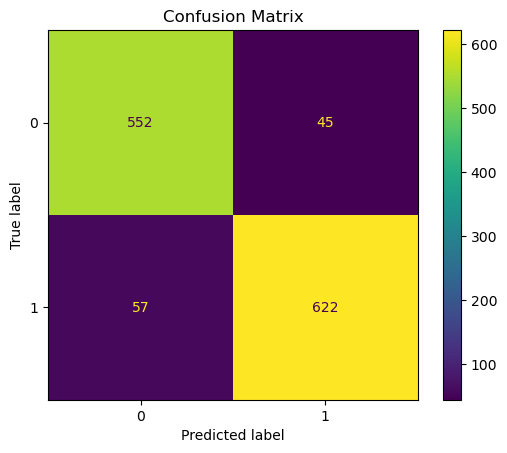

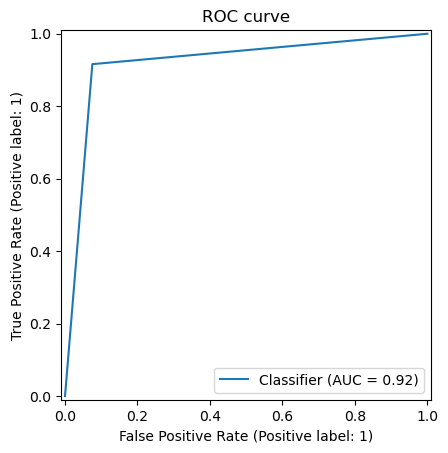

In [78]:
cnn.eval()
val_correct = 0
val_total = 0

cnn_pred = []
y_true = []

with torch.no_grad():
    for inputs, labels in val_set:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = cnn(inputs)
            _, predicted = outputs.max(1)

            cnn_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    f1_cnn = f1_score(y_true, cnn_pred, average='weighted')
    print("Validation:")
    report(y_true, cnn_pred, 'cnn')

In [101]:
#torch.save(cnn.state_dict(), 'cnn_weights_128x128.pth')

### Test the model

In [357]:
cnn.eval()

cnn_pred_test = []

with torch.no_grad():
    for inputs in test_set:
            inputs = inputs.to(device)
            
            outputs = cnn(inputs)
            #predicted = torch.argmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            cnn_pred_test.extend(predicted.cpu().numpy())

#export_csv(cnn_pred_test, test_dataset.get_index_list(), name='cnn')

# Part 2. Feature-Based Classification using a Pretrained CNN

In [5]:
import torch
import torchvision.models as models
import torch.nn as nn
import torchvision.transforms as transforms
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA

import os
import pandas as pd
import numpy as np

## Import ResNet model

In [6]:
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Remove the last fully-connected layer, which is used as the classification layer
ResNet = nn.Sequential(*list(model.children())[:-1])  # The feature extractor we are going to use, we remove the last layer, which categorises images into 1000 classes

ResNet.to(device)

ResNet.eval() # evaluation mode

device

device(type='cpu')

## Extract Train and Test Feature Spaces

In [7]:
train_dir = 'data/train-images/train'
test_dir = 'data/TEST_images/TEST_images'
index_path = 'data/Test-IDs.csv'

### Train and Validation Sets

In [8]:
# this is a counter, used to take every nth and add it to the validation set
global n
n = 4
def counter():
    global n
    result = False
    if n > 0:
        n = n - 1
    else:
        n = 4
        result = True
    return result

In [9]:
from PIL import Image
import numpy as np

image_size = (224, 224) # we resize images to this resolution, which is expected by ResNet
label_dict = {'pleasant':1, 'unpleasant':0}

images_train = []    # this will hold image arrays
labels_train = []    # this will hold the corresponding labels
images_val = []
labels_val = []

total_tensors = []
total_labels = []

for label in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, label)  # create OS independent path
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)  # create OS independent path
            try:
                img = Image.open(img_path).convert('RGB')     # RGB with values [0,255]
                img = img.resize(image_size)                         # resize to same size
                img_np = np.array(img)                                                  # shape [H, W, C]
                img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0  # shape [C, H, W]
                img_tensor = img_tensor.unsqueeze(0)
                img_tensor.to(device)
                
                with torch.no_grad():
                    feat = ResNet(img_tensor).squeeze().numpy()
                
                if not counter():
                    images_train.append(feat)
                    labels_train.append(label_dict[label])
                else:
                    images_val.append(feat)
                    labels_val.append(label_dict[label])

                total_tensors.append(feat)
                total_labels.append(label_dict[label])
                    
            except Exception as e:
                print(f"Failed to load {img_path}: {e}")



In [10]:
X_train = np.array(images_train)
y_train = np.array(labels_train)

X_val = np.array(images_val)
y_val = np.array(labels_val)

X_total = np.concatenate((X_train, X_val))
y_total = np.concatenate((y_train, y_val))

print(f"{len(X_train)}, {len(y_train)}, {len(X_val)}, {len(y_val)}")
print(f"{len(X_total)}, {len(y_total)}")

5101, 5101, 1275, 1275
6376, 6376


In [11]:
X_df = pd.DataFrame(X_total)
y_df = pd.DataFrame(y_total)

X_df.to_csv('X_features.csv', index=False)
y_df.to_csv('y_features.csv', index=False)

### Test Set

In [9]:
images_test = []    # this will hold image arrays

test_ids = pd.read_csv(index_path)
index_list = []

for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)  # create OS independent path
    row = test_ids.loc[test_ids['Filename'] == img_name]
    index_list.append(row['ID'].to_string(index=False)) # appends just the value, without extra info
    try:
        img = Image.open(img_path).convert('RGB')              # grayscale for lower memory usage
        img = img.resize(image_size)                           # resize to same size
        img_np = np.array(img)                                                  # shape [H, W, C]
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0  # shape [C, H, W]
        img_tensor = img_tensor.unsqueeze(0)
        img_tensor.to(device)

        with torch.no_grad():
            feat = ResNet(img_tensor).squeeze().numpy()
        
        images_test.append(feat)
        
    except Exception as e:
        print(f"Failed to load {img_path}: {e}")

In [10]:
X_test = np.array(images_test)

### Export Function

this helper function takes a list with predicted values and exports it as a csv file

In [11]:
def export_csv(pred_list, name='out'):
    if len(pred_list) == len(index_list):
        predictions = pd.DataFrame({
            'ID': index_list,
            'LABEL': pred_list
        })
        predictions.head()
        predictions.to_csv(name+'.csv', index=False)
    else:
        print("Error, list lengths differ")

## Use the Feature Vectors to train traditional classifiers

In [12]:
# Test if we have the right environment selected

import sys
print(sys.executable)

C:\Users\roufosdimitris\anaconda3\envs\ml311\python.exe


### Report Function

In [13]:
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from tabulate import tabulate

def report(y_true, y_score, title=None):
    print()

    # Round scores to 4 decimal points
    accuracy = round(metrics.accuracy_score(y_true, y_score), 4)
    precision = round(metrics.precision_score(y_true, y_score), 4)
    recall = round(metrics.recall_score(y_true, y_score), 4)
    f1 = round(metrics.f1_score(y_true, y_score), 4)

    # Add them to a DataFrame and print them
    scores = {'Metrics':['f1', 'accuracy', 'precision', 'recall'],
              'Scores':[f1, accuracy, precision, recall]}
    score_df = pd.DataFrame(data=scores, index=None)
    if title:
        score_df.to_csv('scores_'+title+'.csv')
    print(tabulate(score_df, headers = 'keys', tablefmt='psql'))

    # Display the Cnfusion Matrix
    cm = confusion_matrix(y_true, y_score)
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=(0,1))
    disp_cm.plot()
    plt.title('Confusion Matrix')
    if title:
        plt.savefig('img_'+title+'_cm.png', bbox_inches='tight')
    plt.show()

    # Display the ROC curve
    RocCurveDisplay.from_predictions(y_true, y_score)
    plt.title('ROC curve')
    if title:
        plt.savefig('img_'+title+'_roc.png', bbox_inches='tight')
    plt.show()

### KNN

In [14]:
from sklearn.neighbors import KNeighborsClassifier

neighbors = [1,3,5,7,9] # We choose odd n. of neighbors to avoid ties
metric_list = ['minkowski', 'manhattan','chebyshev']

max_score_knn = 0
best_knn = None 

for n in neighbors:
    print(f"n: {n}")
    for met in metric_list:
        knn = KNeighborsClassifier(n_neighbors=n, metric=met)
        knn.fit(X_train, y_train)
        y_pred_knn = knn.predict(X_val)
        score = f1_score(y_val, y_pred_knn)

        print(f"   metric: {met}, f1-score: {score:.4f}")

        if score > max_score_knn:
            max_score_knn = score
            best_knn = knn
    print()

n: 1
   metric: minkowski, f1-score: 0.8807
   metric: manhattan, f1-score: 0.8668
   metric: chebyshev, f1-score: 0.8349

n: 3
   metric: minkowski, f1-score: 0.8829
   metric: manhattan, f1-score: 0.8882
   metric: chebyshev, f1-score: 0.8418

n: 5
   metric: minkowski, f1-score: 0.8706
   metric: manhattan, f1-score: 0.8764
   metric: chebyshev, f1-score: 0.8535

n: 7
   metric: minkowski, f1-score: 0.8724
   metric: manhattan, f1-score: 0.8764
   metric: chebyshev, f1-score: 0.8494

n: 9
   metric: minkowski, f1-score: 0.8738
   metric: manhattan, f1-score: 0.8701
   metric: chebyshev, f1-score: 0.8448



Optimal K-NN Hyperparameters:
               n = 3
    dist. metric = manhattan

+----+-----------+----------+
|    | Metrics   |   Scores |
|----+-----------+----------|
|  0 | f1        |   0.8882 |
|  1 | accuracy  |   0.8887 |
|  2 | precision |   0.9527 |
|  3 | recall    |   0.8319 |
+----+-----------+----------+


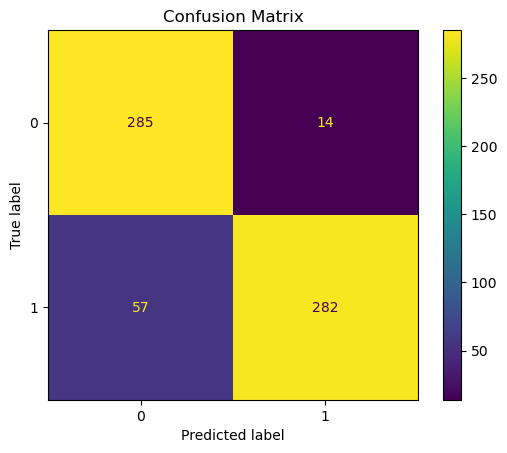

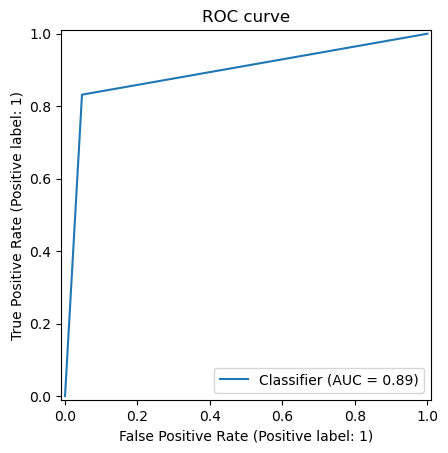

In [69]:
y_knn = best_knn.predict(X_val)

print("Optimal K-NN Hyperparameters:")
print(f"               n = {best_knn.n_neighbors}")
print(f"    dist. metric = {best_knn.metric}")

report(y_val, y_knn, 'knn')

### MLP

In [15]:
import sklearn.neural_network

depth = [1,2,3,4]
width = [512,256,128,64]
act_functions = ['logistic', 'tanh', 'relu']
solvers = ['sgd', 'adam', 'lbfgs']

hidden_layers = 0
act_func = None
opt_alg = None

#### Find the optimal number of layers and neurons

In [17]:
max_score = 0

for l in depth:
    for w in width:
        layers = tuple([w]*l)
        mlp = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=layers)
        mlp.fit(X_train, y_train)
        y_pred_mlp = mlp.predict(X_val)
        f1_mlp = f1_score(y_val, y_pred_mlp)

        print(f'-----layers: {str(layers)}')
        print(f'   f1 score: {f1_mlp:.4f}')

        if f1_mlp > max_score:
            hidden_layers = layers
            max_score = f1_mlp

print(f"\nOptimal layers: {hidden_layers}")
print(f"f1 score:       {max_score:.4f}")

-----layers: (512,)
   f1 score: 0.9450
-----layers: (256,)
   f1 score: 0.9450
-----layers: (128,)
   f1 score: 0.9405
-----layers: (64,)
   f1 score: 0.9391
-----layers: (512, 512)
   f1 score: 0.9481
-----layers: (256, 256)
   f1 score: 0.9435
-----layers: (128, 128)
   f1 score: 0.9424
-----layers: (64, 64)
   f1 score: 0.9359
-----layers: (512, 512, 512)
   f1 score: 0.9466
-----layers: (256, 256, 256)
   f1 score: 0.9477
-----layers: (128, 128, 128)
   f1 score: 0.9467
-----layers: (64, 64, 64)
   f1 score: 0.9449
-----layers: (512, 512, 512, 512)
   f1 score: 0.9525
-----layers: (256, 256, 256, 256)
   f1 score: 0.9438
-----layers: (128, 128, 128, 128)
   f1 score: 0.9467
-----layers: (64, 64, 64, 64)
   f1 score: 0.9363

Optimal layers: (512, 512, 512, 512)
f1 score:       0.9525


#### Find optimal minimizing function

In [18]:
max_score = 0

for s in solvers:
    mlp = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=hidden_layers, solver = s, max_iter = 300)
    mlp.fit(X_train, y_train)
    y_pred_mlp = mlp.predict(X_val)
    f1_mlp = f1_score(y_val, y_pred_mlp)

    print(f"solver: {mlp.solver} | f1 score: {f1_mlp:.4f}")

    if f1_mlp > max_score:
        opt_alg = s
        max_score = f1_mlp

print(f"\nBest solver for MLP: {opt_alg}")
print(f"f1 score: {max_score:.4f}")

solver: sgd | f1 score: 0.9572
solver: adam | f1 score: 0.9433
solver: lbfgs | f1 score: 0.9481

Best solver for MLP: sgd
f1 score: 0.9572


#### Find optimal activation function

In [19]:
max_score = 0

for act in act_functions:
    mlp = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=hidden_layers, solver=opt_alg, activation=act)
    mlp.fit(X_train, y_train)
    y_pred_mlp = mlp.predict(X_val)
    f1_mlp = f1_score(y_val, y_pred_mlp)

    print(f"function: {mlp.activation} | f1 score: {f1_mlp:.4f}")

    if f1_mlp > max_score:
        act_func = act
        max_score = f1_mlp

print(f"\nOptimal activation function for MLP: {act_func}")
print(f"f1 score: {max_score:.4f}")

function: logistic | f1 score: 0.6940


C:\Users\roufosdimitris\anaconda3\envs\ml311\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


function: tanh | f1 score: 0.9333
function: relu | f1 score: 0.9391

Optimal activation function for MLP: relu
f1 score: 0.9391


C:\Users\roufosdimitris\anaconda3\envs\ml311\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


#### Final model with tuned hyperparameters

In [16]:
# These should have values from earlier cells

MLP = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=hidden_layers,
                                           activation=act_func, 
                                           solver=opt_alg,
                                           max_iter = 500)
MLP.fit(X_train, y_train)
mlp_prediction = MLP.predict(X_val)

print('Optimal parameters for MLP:')
print(MLP)

report(y_val, mlp_prediction, 'mlp')

InvalidParameterError: The 'activation' parameter of MLPClassifier must be a str among {'tanh', 'relu', 'identity', 'logistic'}. Got None instead.

In [17]:
MLP = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(256,256,256),
                                           activation='relu', 
                                           solver='sgd',
                                           max_iter = 500)

In [18]:
MLP.fit(X_total,y_total)

MLPClassifier(hidden_layer_sizes=(256, 256, 256), max_iter=500, solver='sgd')

In [21]:
path = 'data/myFace'

myface_train = []
labels_myface = []

face1 = Image.open(f"{path}/PleasantFace.jpg").convert('RGB')     # RGB with values [0,255]
face1 = img.resize(image_size)                         # resize to same size
face1_np = np.array(img)                                                  # shape [H, W, C]
face1_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0  # shape [C, H, W]
face1_tensor = img_tensor.unsqueeze(0)
face1_tensor.to(device)

with torch.no_grad():
    feat = ResNet(face1_tensor).squeeze().numpy()

myface_train.append(feat)
labels_myface.append(1)

face0 = Image.open(f"{path}/PleasantFace.jpg").convert('RGB')     # RGB with values [0,255]
face0 = img.resize(image_size)                         # resize to same size
face0_np = np.array(img)                                                  # shape [H, W, C]
face0_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0  # shape [C, H, W]
face0_tensor = img_tensor.unsqueeze(0)
face0_tensor.to(device)

with torch.no_grad():
    feat = ResNet(face0_tensor).squeeze().numpy()

myface_train.append(feat)
labels_myface.append(0)

X_face = np.array(images_train)
y_face = np.array(labels_train)

RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 1, 3, 224, 224]

In [21]:
MLP.fit(X_total,y_total)
results = MLP.predict(X_test)
#export_csv(results, 'mlp')

### SVM

In [79]:
from sklearn.svm import SVC

kernels = ['linear', 'rbf']
C_values = [0.1, 1, 10, 100]

kernel = ''
C = 0

In [80]:
max_score = 0

for k in kernels:
    svm = SVC(kernel=k)
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_val)
    f1_svm = f1_score(y_val, y_pred_svm)

    print(f'-----Kernel: {k}')
    print(f"   f1 score: {f1_svm:.4f}")

    if f1_svm > max_score:
        max_score = f1_svm
        kernel = k

print(f'\nOptimal kernel: {kernel}')

-----Kernel: linear
   f1 score: 0.9343
-----Kernel: rbf
   f1 score: 0.9419

Optimal kernel: rbf


In [82]:
max_score = 0

for c in C_values:
    svm = sklearn.svm.SVC(kernel=kernel, C=c)
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_val)
    f1_svm = f1_score(y_val, y_pred_svm)

    print(f'----C value: {c}')
    print(f"   f1 score: {f1_svm:.4f}")

    if f1_svm > max_score:
        max_score = f1_svm
        C = c

print(f'\nOptimal C value: {C}')


----C value: 0.1
   f1 score: 0.9184
----C value: 1
   f1 score: 0.9419
----C value: 10
   f1 score: 0.9469
----C value: 100
   f1 score: 0.9461

Optimal C value: 10



+----+-----------+----------+
|    | Metrics   |   Scores |
|----+-----------+----------|
|  0 | f1        |   0.9469 |
|  1 | accuracy  |   0.9435 |
|  2 | precision |   0.9469 |
|  3 | recall    |   0.9469 |
+----+-----------+----------+


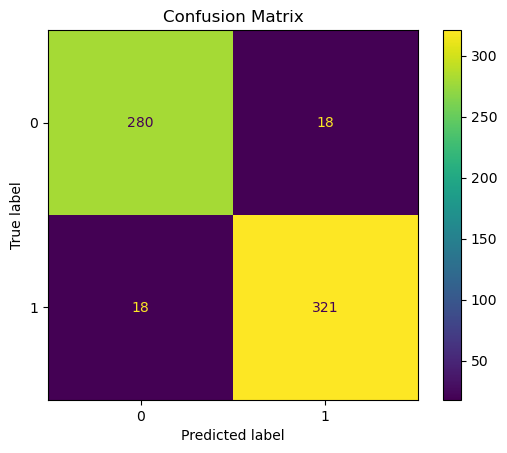

Error, list lengths differ


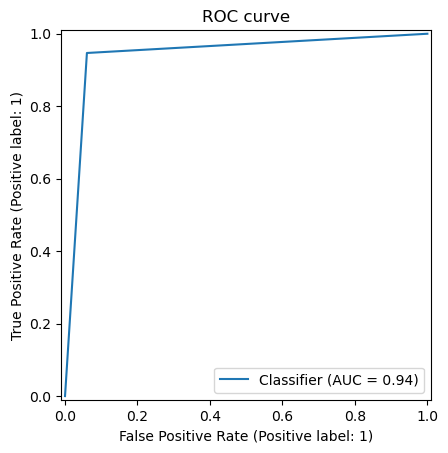

In [83]:
SVM = sklearn.svm.SVC(kernel=kernel, C=C)

SVM.fit(X_train,y_train)
svm_prediction = SVM.predict(X_val)
report(y_val,svm_prediction, 'SVM')

SVM.fit(X_total,y_total)

results_svm = SVM.predict(X_test)
#export_csv(results_svm, 'svm')

### Logistic Regression

In [84]:
from sklearn.linear_model import LogisticRegression

C_log = 0

In [85]:
max_score = 0

for c in C_values:
    log_reg = LogisticRegression(C=c, max_iter=300)

    log_reg.fit(X_train, y_train)
    y_pred_logistic = log_reg.predict(X_val)
    f1_logistic = f1_score(y_val, y_pred_logistic)

    print(f'----C value: {c}')
    print(f'   f1 score: {f1_logistic:.4f}')

    if f1_logistic > max_score:
        max_score = f1_logistic
        C_log = c

print(f'\nOptimal C value: {C_log}')

----C value: 0.1
   f1 score: 0.9407
----C value: 1
   f1 score: 0.9453


C:\Users\roufosdimitris\anaconda3\envs\ml311\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


----C value: 10
   f1 score: 0.9370
----C value: 100
   f1 score: 0.9327

Optimal C value: 1


C:\Users\roufosdimitris\anaconda3\envs\ml311\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



+----+-----------+----------+
|    | Metrics   |   Scores |
|----+-----------+----------|
|  0 | f1        |   0.9327 |
|  1 | accuracy  |   0.9278 |
|  2 | precision |   0.9246 |
|  3 | recall    |   0.941  |
+----+-----------+----------+


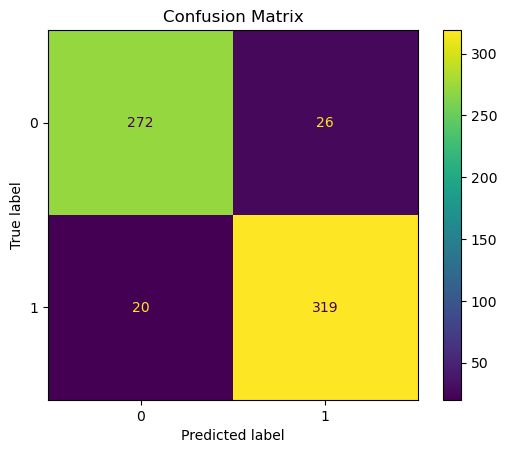

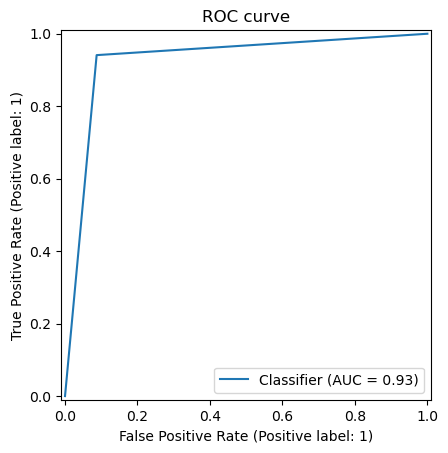

In [86]:
Regression = LogisticRegression(C=C_log, max_iter=300)
Regression.fit(X_train, y_train)
pred_logistic = log_reg.predict(X_val)
report(y_val, pred_logistic, 'regression')

### Ensemble Learning

#### Random Forest

In [87]:
from sklearn.ensemble import RandomForestClassifier

n_trees = [10, 100, 500, 1000, 1500]
max_depth = [2, 5, 10, 25, 50]

max_score_forest = 0
optimal_estimators = 0
optimal_depth = 0

In [88]:
for n in n_trees:
    forest = RandomForestClassifier(n_estimators=n)
    forest.fit(X_train, y_train)
    y_pred_forest = forest.predict(X_val)
    score = f1_score(y_val, y_pred_forest)

    print(f'N. of Estimators: {n}\n        f1-score: {score:.4f}')

    if score > max_score_forest:
        max_score_forest = score
        optimal_estimators = forest.n_estimators

N. of Estimators: 10
        f1-score: 0.8700
N. of Estimators: 100
        f1-score: 0.9242
N. of Estimators: 500
        f1-score: 0.9320
N. of Estimators: 1000
        f1-score: 0.9288
N. of Estimators: 1500
        f1-score: 0.9244


In [89]:
for depth in max_depth:
    forest = RandomForestClassifier(n_estimators=optimal_estimators, max_depth=depth)
    forest.fit(X_train, y_train)
    y_pred_forest = forest.predict(X_val)
    score = f1_score(y_val, y_pred_forest)

    print(f'Max Depth: {depth}\n     f1-score: {score:.4f}')

    if score > max_score_forest:
        max_score_forest = score
        optimal_depth = forest.max_depth

Max Depth: 2
     f1-score: 0.8447
Max Depth: 5
     f1-score: 0.8906
Max Depth: 10
     f1-score: 0.9251
Max Depth: 25
     f1-score: 0.9228
Max Depth: 50
     f1-score: 0.9322


Optimal Random Forest Hyperparameters:
       n = 500
   depth = 50

+----+-----------+----------+
|    | Metrics   |   Scores |
|----+-----------+----------|
|  0 | f1        |   0.9231 |
|  1 | accuracy  |   0.9184 |
|  2 | precision |   0.9258 |
|  3 | recall    |   0.9204 |
+----+-----------+----------+


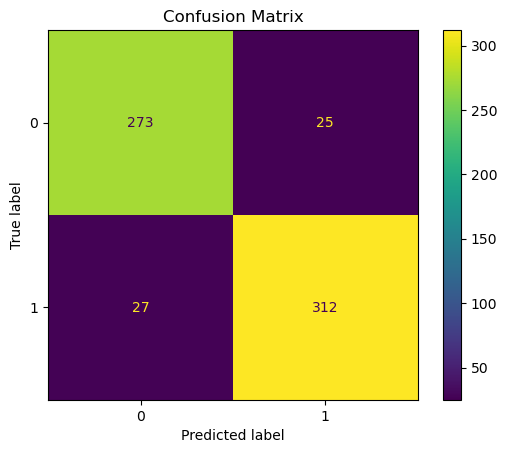

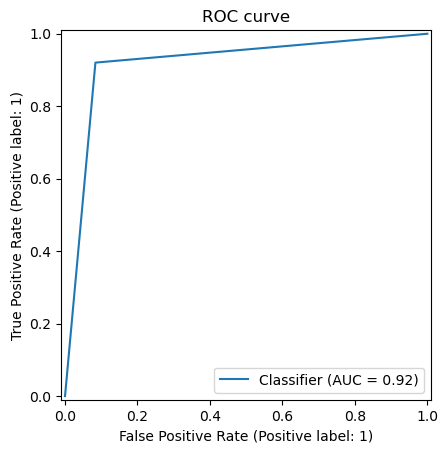

In [91]:
forest = RandomForestClassifier(n_estimators=optimal_estimators,
                                max_depth=optimal_depth)

forest.fit(X_train, y_train)
forest_prediction = forest.predict(X_val)

print("Optimal Random Forest Hyperparameters:")
print(f"       n = {optimal_estimators}")
print(f"   depth = {optimal_depth}")

report(y_val, forest_prediction, 'forest')

In [93]:
forest.fit(X_total, y_total)
forest_test = forest_prediction = forest.predict(X_test)
#export_csv(forest_test, 'forest')

Error, list lengths differ


#### Bagging

In [94]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

n_estimators = [10, 15, 20]

max_score_bagging = 0
best_bagging = None 
best_report_bagging = ""

for n in n_estimators:
    bagging = BaggingClassifier(estimator=SVC(), n_estimators=n, random_state=0)
    bagging.fit(X_train, y_train)
    y_pred_bagging = bagging.predict(X_val)
    score = f1_score(y_val, y_pred_bagging)

    print(f'N. of Estimators: {n}\n     f1-score: {score:.4f}')

    if score > max_score_bagging:
        max_score_bagging = score
        best_bagging = bagging

N. of Estimators: 10
     f1-score: 0.9417
N. of Estimators: 15
     f1-score: 0.9403
N. of Estimators: 20
     f1-score: 0.9403


Optimal Bagging Hyperparameters:
       n = 10

+----+-----------+----------+
|    | Metrics   |   Scores |
|----+-----------+----------|
|  0 | f1        |   0.9417 |
|  1 | accuracy  |   0.9388 |
|  2 | precision |   0.9545 |
|  3 | recall    |   0.9292 |
+----+-----------+----------+


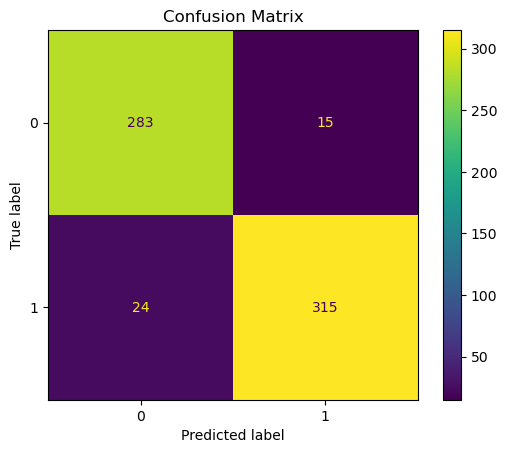

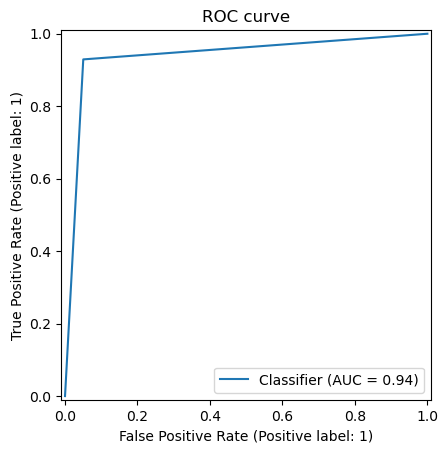

In [98]:
print("Optimal Bagging Hyperparameters:")
print(f"       n = {best_bagging.n_estimators}")

pred_bagging = best_bagging.predict(X_val)
report(y_val, pred_bagging, 'bagging')

#### AdaBoost

In [96]:
from sklearn.ensemble import AdaBoostClassifier

n_estims = [100, 120, 140, 160, 180, 200]

max_score_ada = 0
best_ada = None 

for n in n_estims:
    ada = AdaBoostClassifier(estimator=SVC(), n_estimators=n, random_state=0)
    ada.fit(X_train, y_train)
    y_pred_ada = ada.predict(X_val)
    score = f1_score(y_val, y_pred_ada)

    print(f'N. of Estimators: {n}\n     f1-score: {score:.4f}')

    if score > max_score_ada:
        max_score_ada = score
        best_ada = ada

N. of Estimators: 100
     f1-score: 0.6947
N. of Estimators: 120
     f1-score: 0.6947
N. of Estimators: 140
     f1-score: 0.6947
N. of Estimators: 160
     f1-score: 0.6947
N. of Estimators: 180
     f1-score: 0.6947
N. of Estimators: 200
     f1-score: 0.6947


Optimal AdaBoost Hyperparameter:
       n = 100

+----+-----------+----------+
|    | Metrics   |   Scores |
|----+-----------+----------|
|  0 | f1        |   0.6947 |
|  1 | accuracy  |   0.5322 |
|  2 | precision |   0.5322 |
|  3 | recall    |   1      |
+----+-----------+----------+


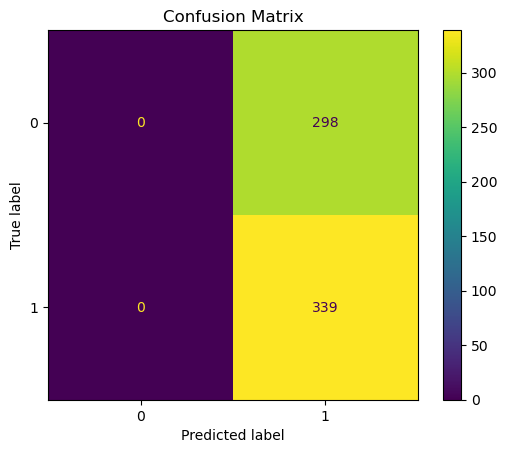

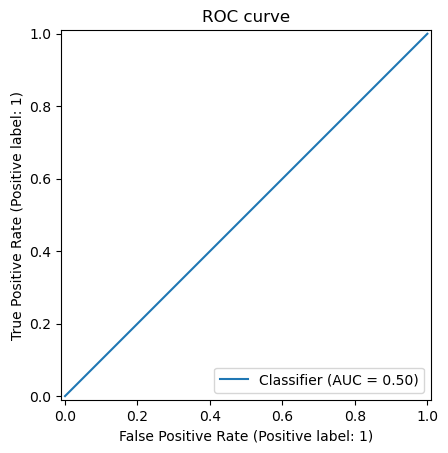

In [99]:
print("Optimal AdaBoost Hyperparameter:")
print(f"       n = {best_ada.n_estimators}")

pred_ada = best_ada.predict(X_val)
report(y_val, pred_ada, 'ada')